In [1]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
all_data = pd.read_csv('../data/general_df.csv')

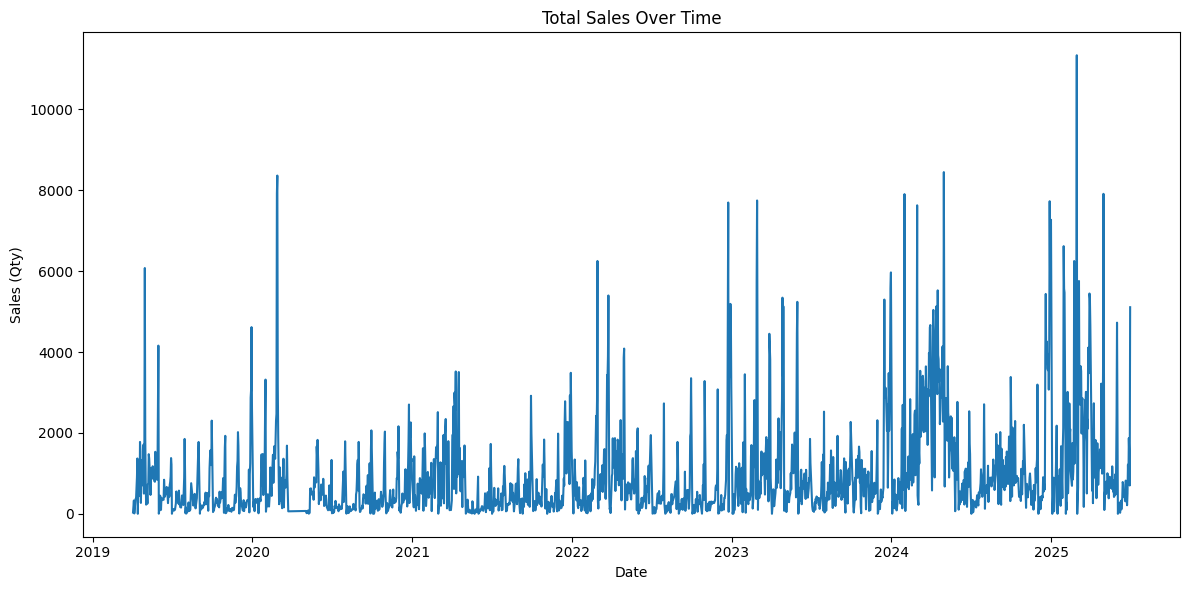

In [3]:
# Group data by Date and sum Qty to get total sales per date
sales_per_date = all_data.groupby('Date')['Qty'].sum().reset_index()

# Convert 'Date' to datetime for proper plotting, if not already
sales_per_date['Date'] = pd.to_datetime(sales_per_date['Date'])

# Plot using matplotlib
plt.figure(figsize=(12,6))
plt.plot(sales_per_date['Date'], sales_per_date['Qty'])
plt.xlabel('Date')
plt.ylabel('Sales (Qty)')
plt.title('Total Sales Over Time')
plt.tight_layout()
plt.show()


In [4]:
all_data_monthly = pd.read_csv('../data/general_df_monthly.csv')

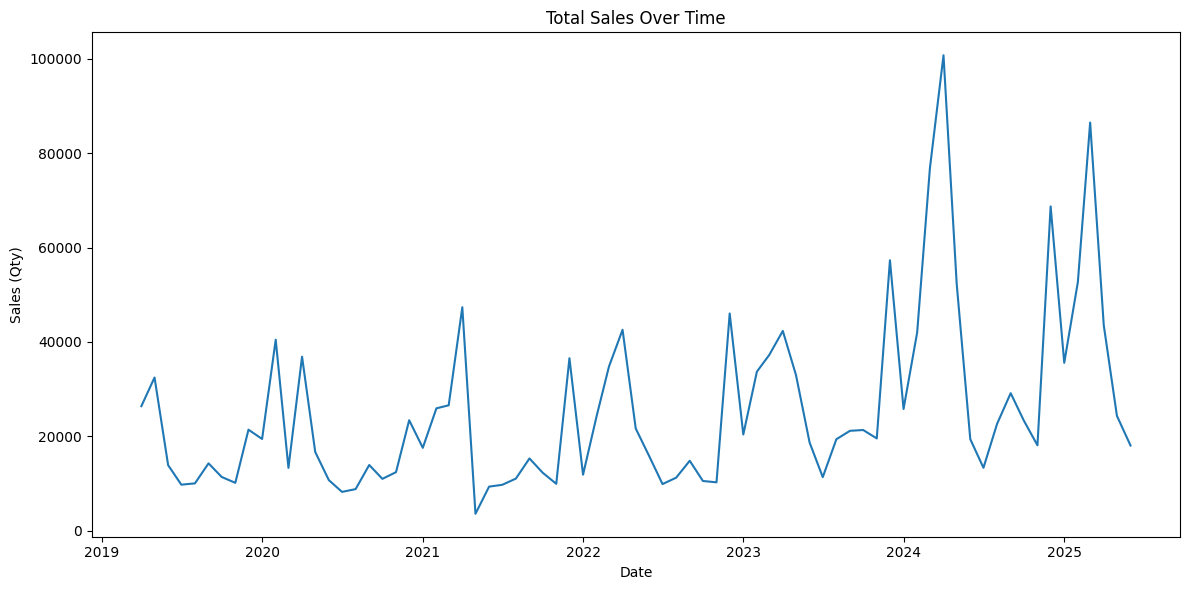

In [5]:
# Group data by Date and sum Qty to get total sales per date
sales_per_month = all_data_monthly.groupby('Date')['Qty'].sum().reset_index()

# Convert 'Date' to datetime for proper plotting, if not already
sales_per_month['Date'] = pd.to_datetime(sales_per_month['Date'])

# Plot using matplotlib
plt.figure(figsize=(12,6))
plt.plot(sales_per_month['Date'], sales_per_month['Qty'])
plt.xlabel('Date')
plt.ylabel('Sales (Qty)')
plt.title('Total Sales Over Time')
plt.tight_layout()
plt.show()


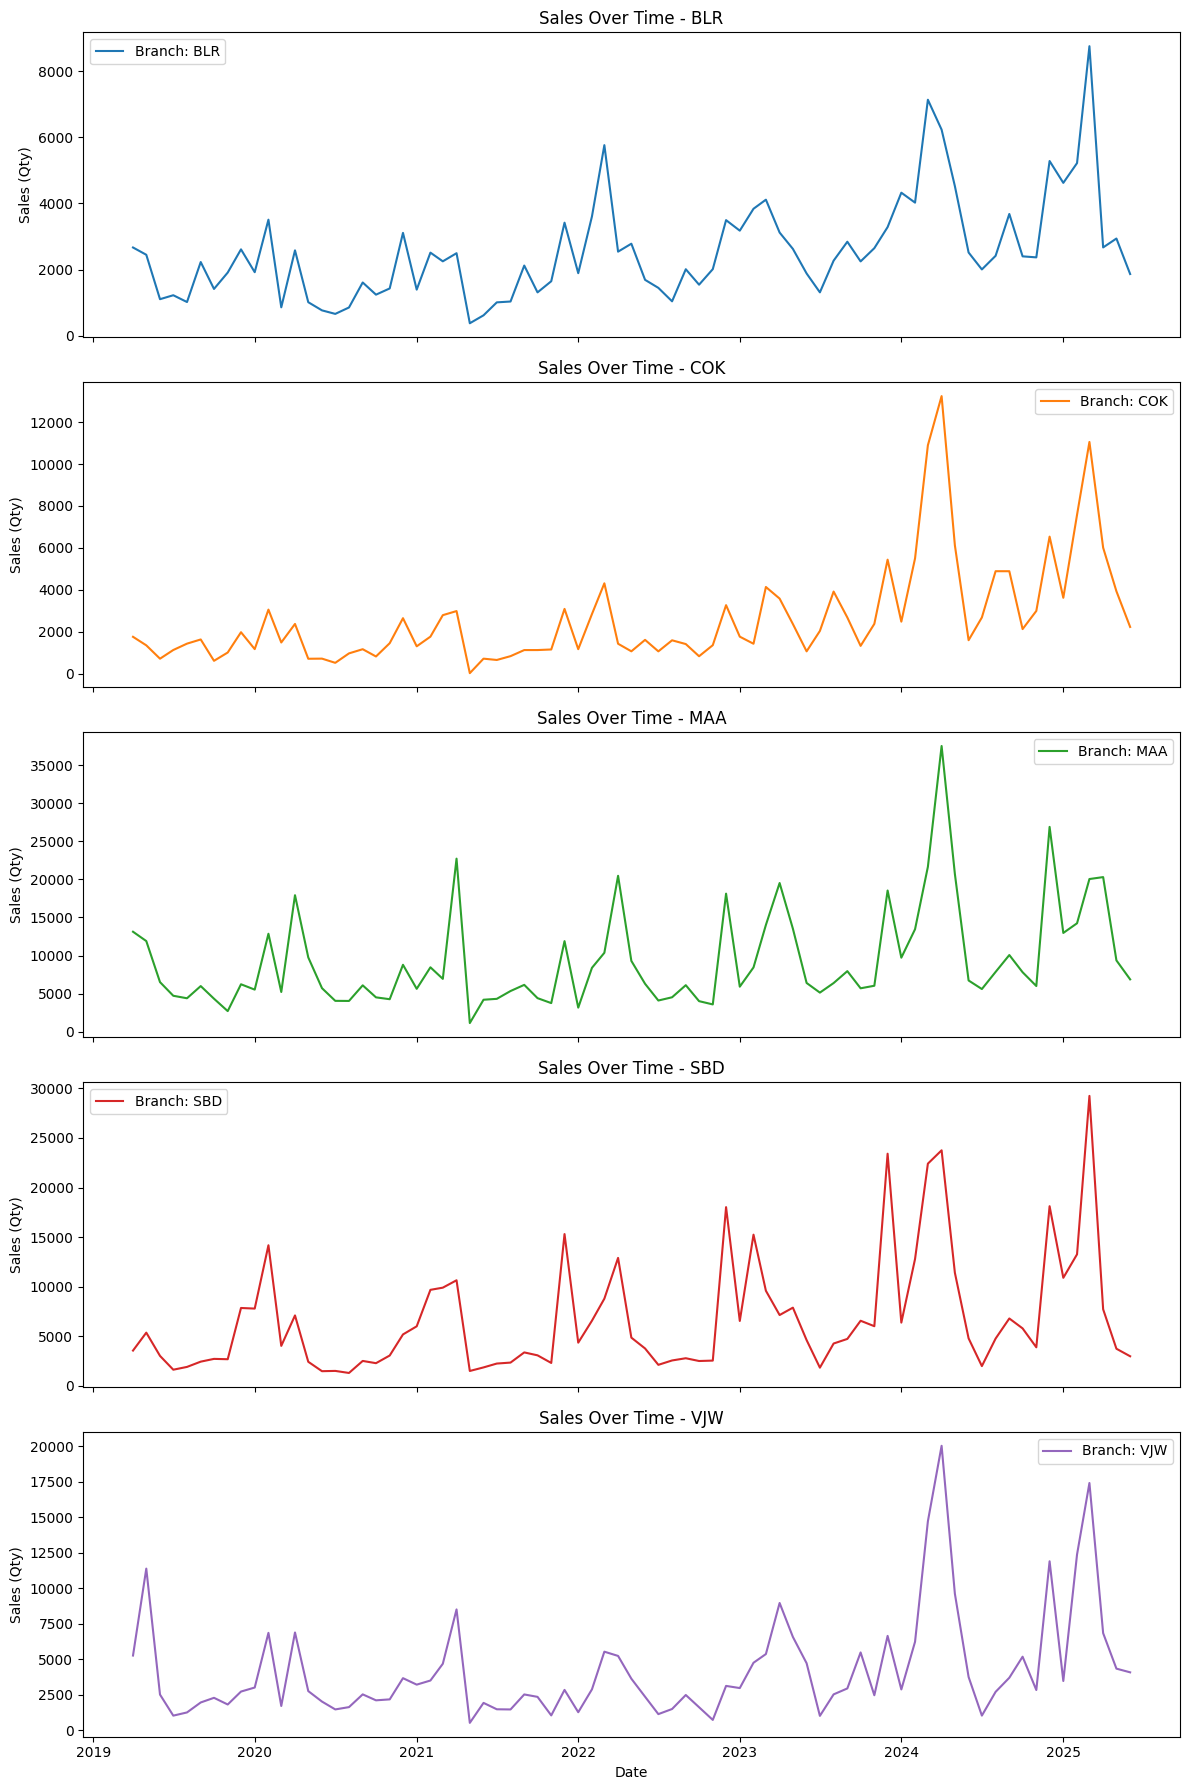

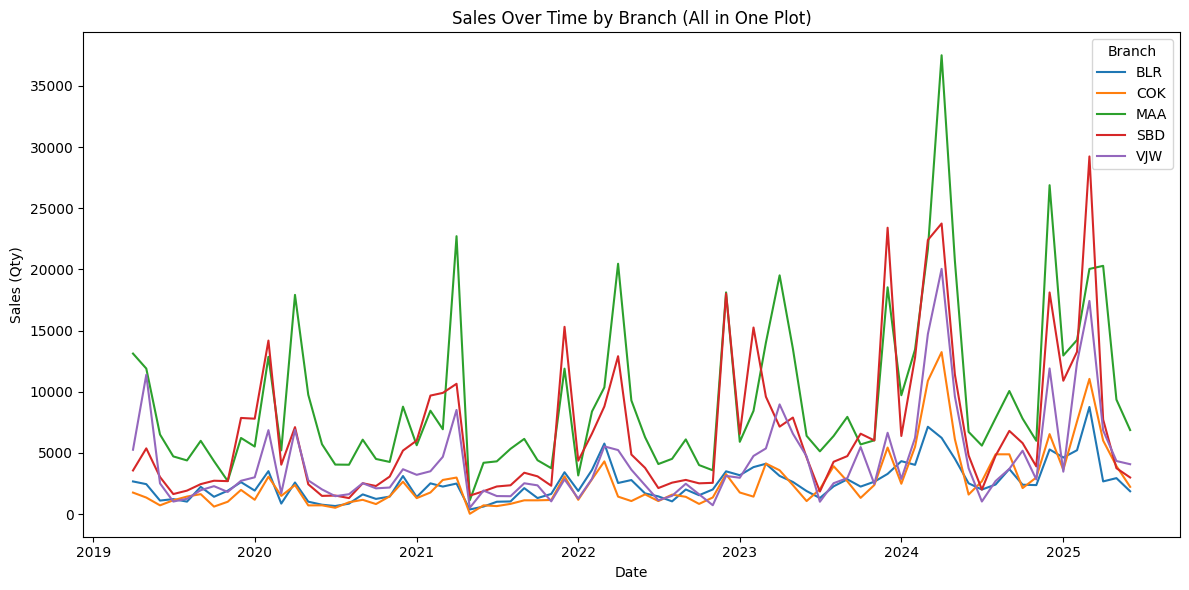

In [6]:
# Plot 5 separate subplots, one for each Branch, and an overlapping plot for all Branches

branches = all_data_monthly['Branch'].unique()[:5]  # Ensure only 5 branches

# Prepare color palette
colors = plt.cm.tab10.colors

# Create 5 subplots (one for each branch)
fig, axs = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
for i, branch in enumerate(branches):
    df_branch = all_data_monthly[all_data_monthly['Branch'] == branch]
    df_branch = df_branch.groupby('Date')['Qty'].sum().reset_index()
    df_branch['Date'] = pd.to_datetime(df_branch['Date'])
    axs[i].plot(df_branch['Date'], df_branch['Qty'], color=colors[i % len(colors)], label=f"Branch: {branch}")
    axs[i].set_ylabel('Sales (Qty)')
    axs[i].set_title(f'Sales Over Time - {branch}')
    axs[i].legend()
axs[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Now, overlapping plot for all 5 branches
plt.figure(figsize=(12,6))
for i, branch in enumerate(branches):
    df_branch = all_data_monthly[all_data_monthly['Branch'] == branch]
    df_branch = df_branch.groupby('Date')['Qty'].sum().reset_index()
    df_branch['Date'] = pd.to_datetime(df_branch['Date'])
    plt.plot(df_branch['Date'], df_branch['Qty'], color=colors[i % len(colors)], label=branch)
plt.xlabel('Date')
plt.ylabel('Sales (Qty)')
plt.title('Sales Over Time by Branch (All in One Plot)')
plt.legend(title="Branch")
plt.tight_layout()
plt.show()



In [7]:
import plotly.graph_objs as go
import plotly.express as px

# Calculate financial year for each row: FY is from Apr to Mar
def get_fin_year(dt):
    dt = pd.to_datetime(dt)
    year = dt.year
    if dt.month >= 4:
        return f"{year}-{str(year+1)[-2:]}"
    else:
        return f"{year-1}-{str(year)[-2:]}"
    
fy_sales = all_data_monthly.copy()
fy_sales['FinYear'] = fy_sales['Date'].apply(get_fin_year)

# Filter FYs from FY 2019-20 to FY 2024-25
fy_list = []
start_year = 2019
for y in range(start_year, 2025):
    fy_list.append(f"{y}-{str(y+1)[-2:]}")

# Total sales for each branch by FY
fy_branch_qty = fy_sales.groupby(['FinYear', 'Branch'])['Qty'].sum().reset_index()
fy_branch_qty = fy_branch_qty[fy_branch_qty['FinYear'].isin(fy_list)]

# Compute YoY growth for each branch across FYs
branch_growth = []
for branch in fy_branch_qty['Branch'].unique():
    df = fy_branch_qty[fy_branch_qty['Branch'] == branch].sort_values('FinYear').set_index('FinYear')
    for i in range(1, len(fy_list)):
        curr_fy = fy_list[i]
        prev_fy = fy_list[i-1]
        if curr_fy in df.index and prev_fy in df.index:
            prev = df.loc[prev_fy, 'Qty']
            curr = df.loc[curr_fy, 'Qty']
            growth = ((curr - prev) / prev) * 100 if prev != 0 else None
            branch_growth.append({'Branch': branch, 'FinYear': curr_fy, 'GrowthRate(%)': growth, "PrevQty": prev, "CurrQty": curr})
branch_growth_df = pd.DataFrame(branch_growth)

# Cumulative FY (all branches): total and growth
fy_total_qty = fy_sales.groupby('FinYear')['Qty'].sum().reset_index()
fy_total_qty = fy_total_qty[fy_total_qty['FinYear'].isin(fy_list)].set_index('FinYear')
cumulative_growth = []
for i in range(1, len(fy_list)):
    curr_fy = fy_list[i]
    prev_fy = fy_list[i-1]
    if curr_fy in fy_total_qty.index and prev_fy in fy_total_qty.index:
        prev = fy_total_qty.loc[prev_fy, 'Qty']
        curr = fy_total_qty.loc[curr_fy, 'Qty']
        growth = ((curr - prev) / prev) * 100 if prev != 0 else None
        cumulative_growth.append({'FinYear': curr_fy, 'CumulativeGrowthRate(%)': growth, "PrevQty": prev, "CurrQty": curr})
cumulative_growth_df = pd.DataFrame(cumulative_growth)

# Plot: Branchwise Growth using Plotly
fig = go.Figure()
for branch in branch_growth_df['Branch'].unique():
    df = branch_growth_df[branch_growth_df['Branch'] == branch]
    fig.add_trace(go.Scatter(
        x=df['FinYear'],
        y=df['GrowthRate(%)'],
        mode='lines+markers',
        name=branch,
        customdata = df[['PrevQty','CurrQty']],
        hovertemplate='<b>FY: %{x}</b><br>Growth Rate: %{y:.2f}%<br>Prev Sales: %{customdata[0]:,.0f}<br>Curr Sales: %{customdata[1]:,.0f}<extra>Branch: '+branch+'</extra>'
    ))
fig.update_layout(title="Branchwise Financial Year-over-Year Growth Rate (%)",
                  xaxis_title="Financial Year",
                  yaxis_title="Growth Rate (%)",
                  legend_title="Branch",
                  hovermode='x unified',
                  template="plotly_white")
fig.show()

# Plot: Cumulative Growth using Plotly
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=cumulative_growth_df['FinYear'],
    y=cumulative_growth_df['CumulativeGrowthRate(%)'],
    mode='lines+markers',
    name='Cumulative',
    customdata = cumulative_growth_df[['PrevQty','CurrQty']],
    hovertemplate='<b>FY: %{x}</b><br>Growth Rate: %{y:.2f}%<br>Prev Sales: %{customdata[0]:,.0f}<br>Curr Sales: %{customdata[1]:,.0f}<extra>Cumulative</extra>'
))
fig2.update_layout(title="Cumulative Financial Year-over-Year Growth Rate (%)",
                   xaxis_title="Financial Year",
                   yaxis_title="Growth Rate (%)",
                   hovermode='x unified',
                   template="plotly_white")
fig2.show()

# Plot: Total Sales Every Financial Year using Plotly
fy_total_qty_reset = fy_total_qty.reset_index()
fig3 = px.bar(fy_total_qty_reset, x='FinYear', y='Qty',
              hover_data={'FinYear':True, 'Qty':':,.0f'},
              labels={'Qty':'Total Sales (Qty)', 'FinYear':'Financial Year'},
              title='Total Sales (Qty) by Financial Year')
fig3.update_traces(hovertemplate='<b>FY: %{x}</b><br>Total Sales: %{y:,.0f}')
fig3.update_layout(template="plotly_white")
fig3.show()



